<a href="https://colab.research.google.com/github/90splayer/AI-HEALTH-LAB/blob/main/Supervised_and_unsupervised_learning_practice_week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Chibuzor Ojogbo
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score
from sklearn import linear_model

Step 1 Load the dataset, split to training and test sets, train one or more models on the training data, and evaluate the performance on the test data

This task aims to train one or more classification models using [Breast cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset). Please click to see descriptive information about this dataset. We will provide instructions and example code step by step for you.

In [2]:
# Load the breast cancer dataset
bcancer = datasets.load_breast_cancer()
bcancer_X, bcancer_y = bcancer.data, bcancer.target

In [5]:
## Split training and test set first ## 10% was considered as test and remaining as train
bcancer_X_train, bcancer_X_test, bcancer_y_train, bcancer_y_test = train_test_split(
    bcancer_X, bcancer_y, test_size=0.1, random_state=42)

Visualise data

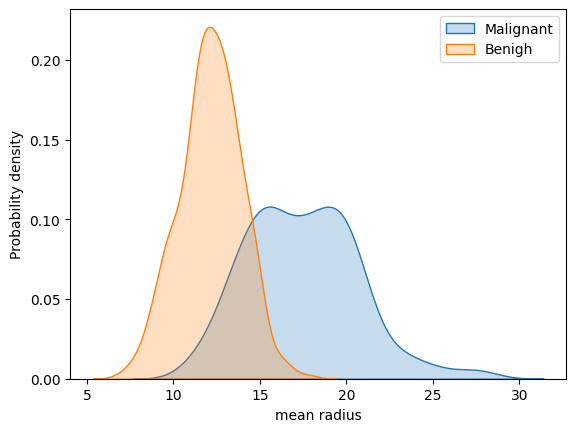

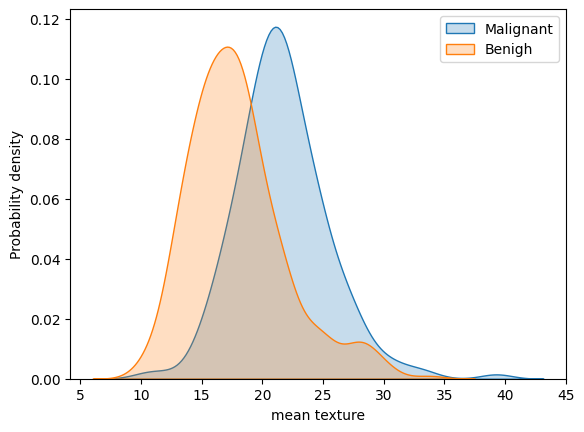

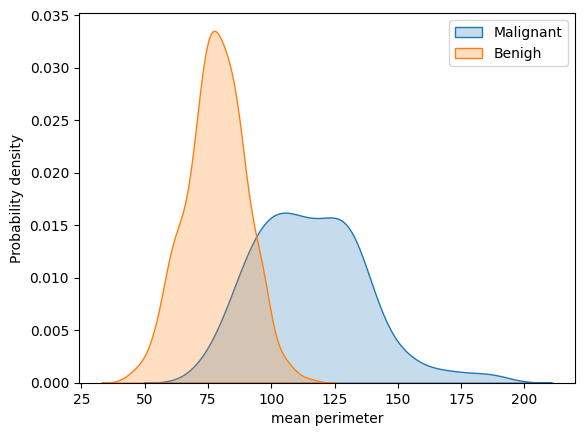

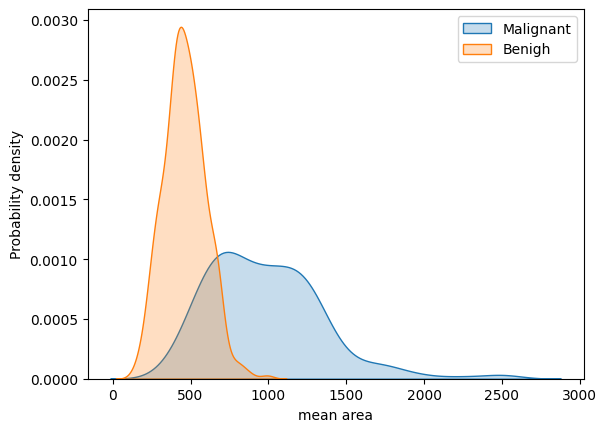

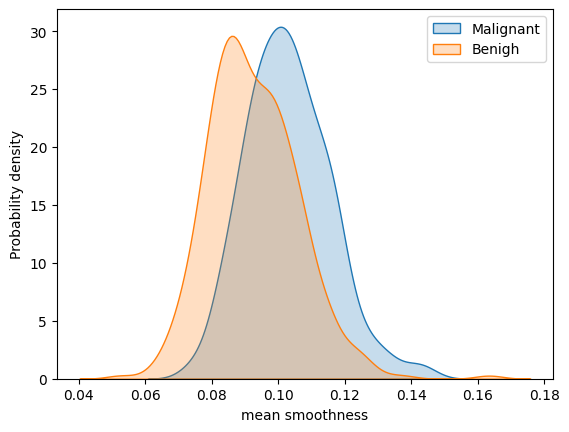

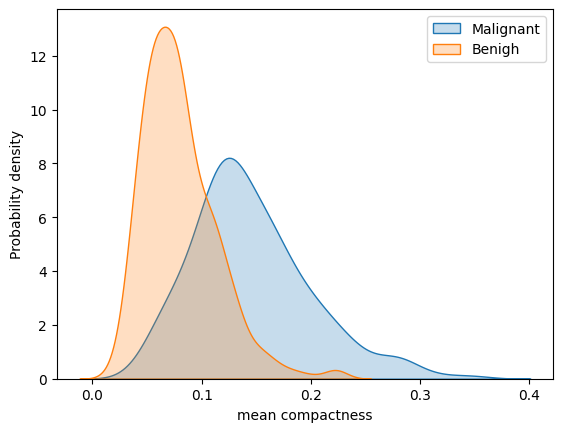

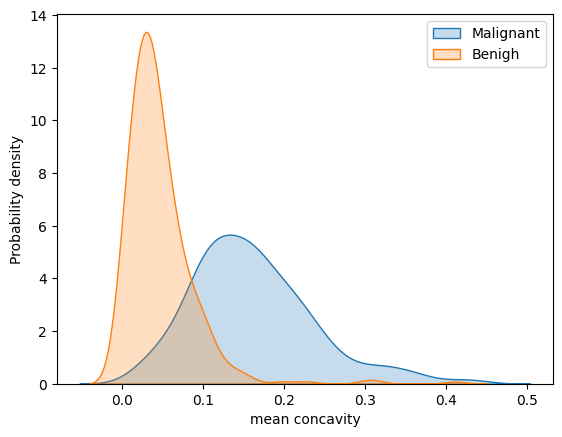

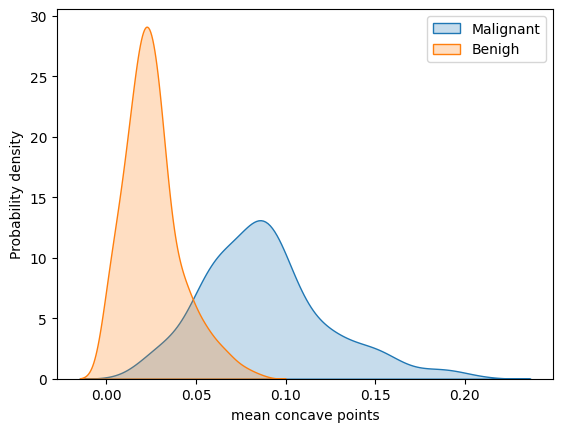

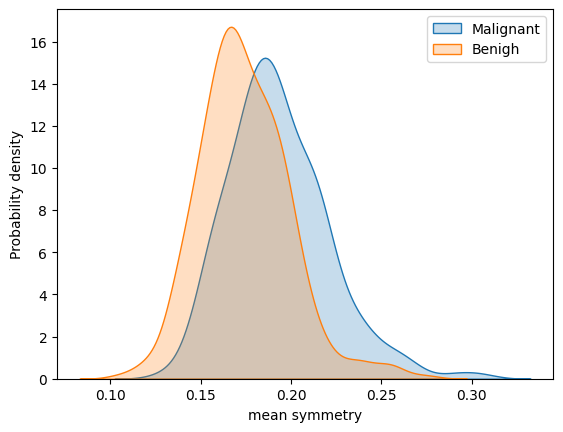

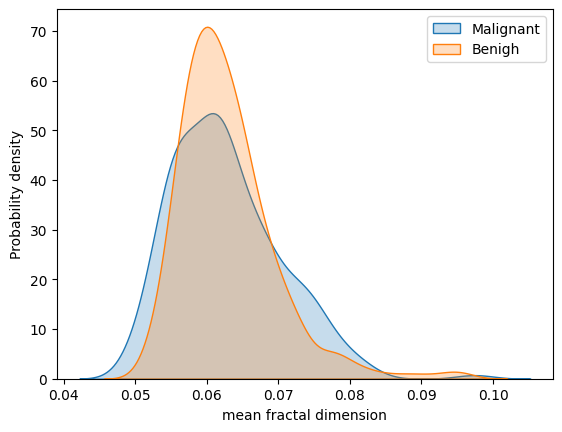

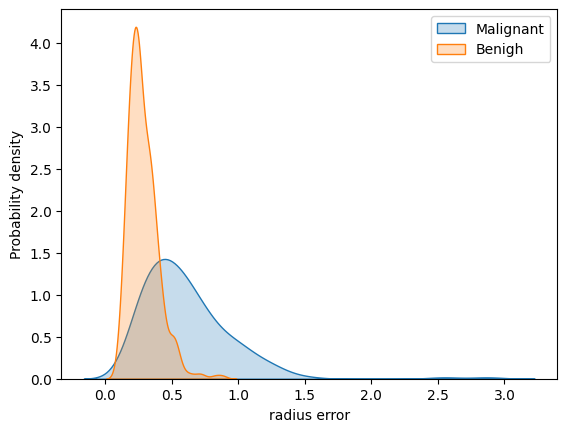

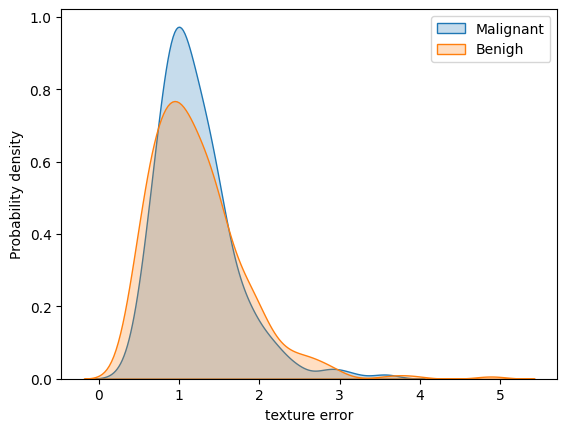

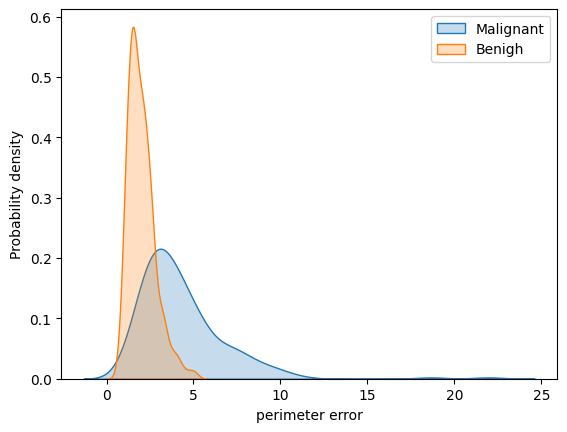

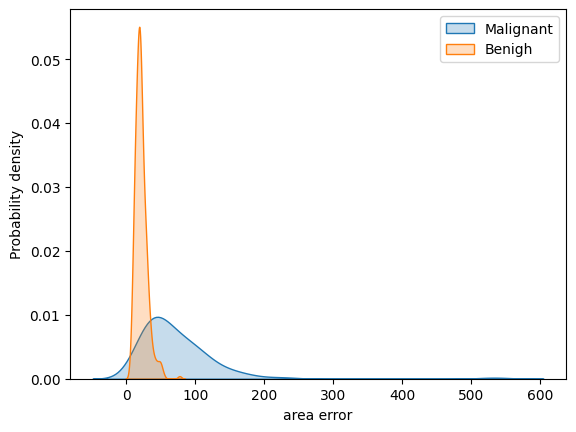

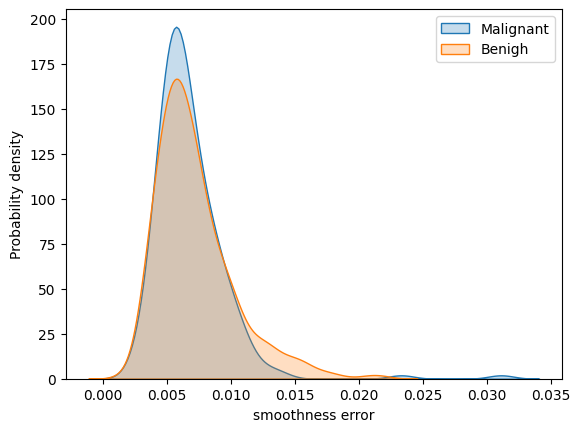

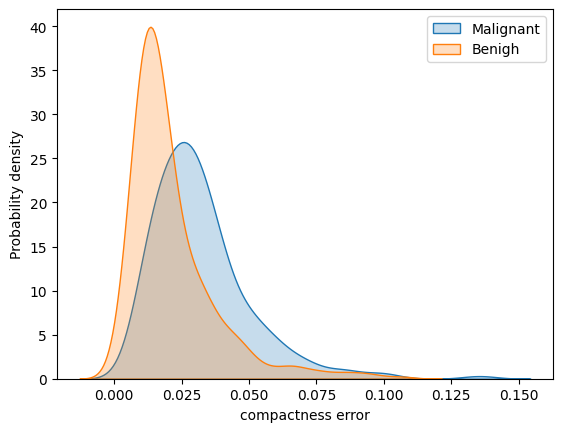

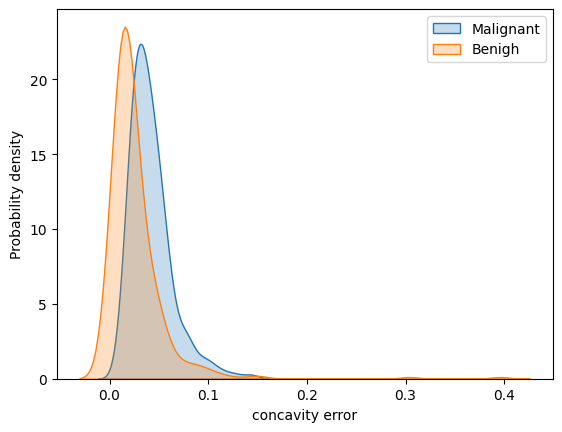

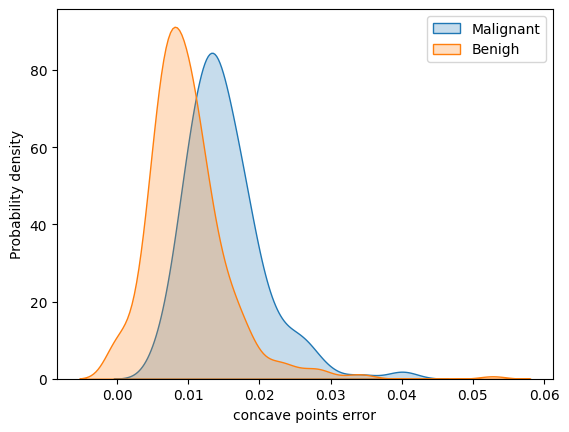

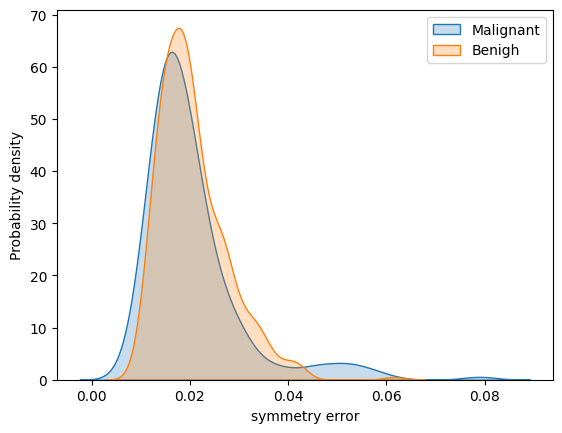

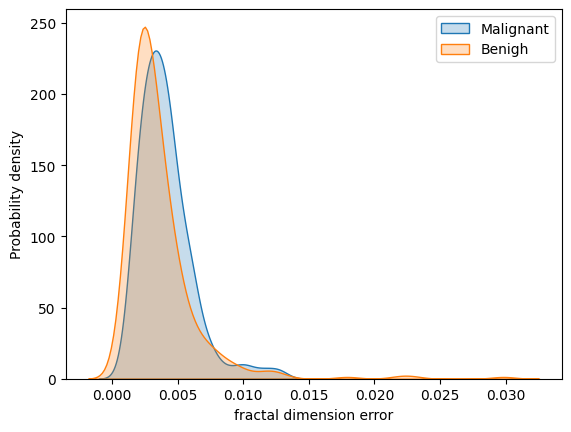

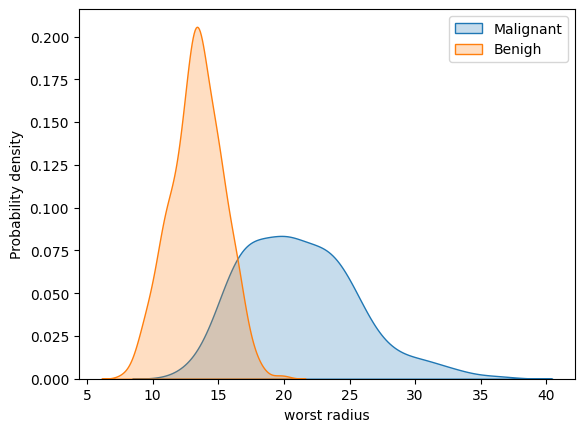

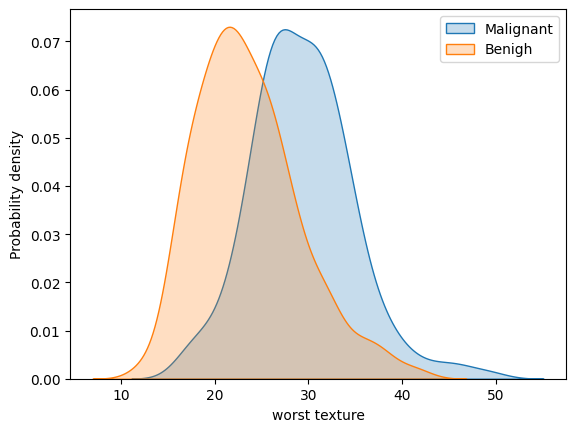

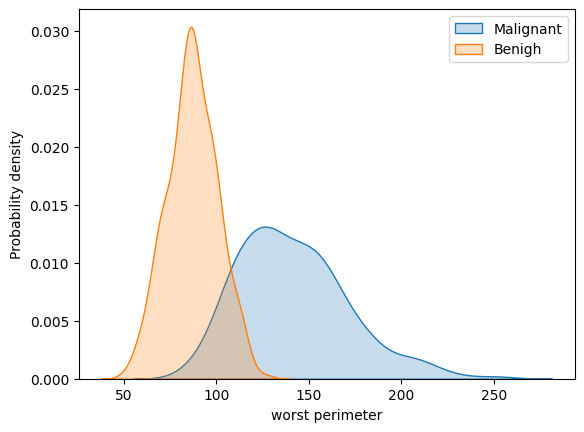

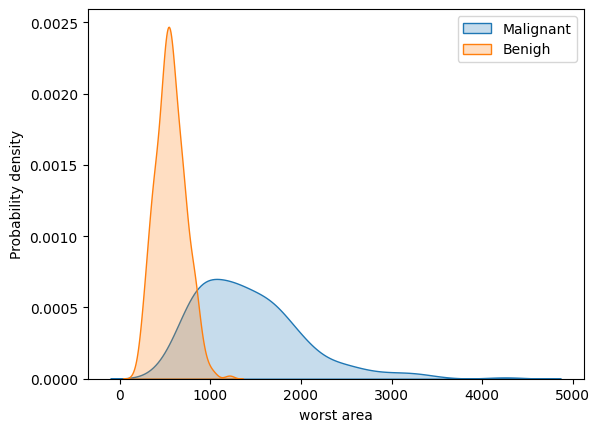

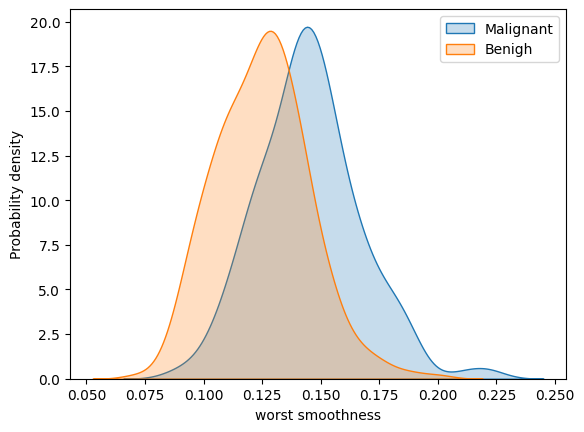

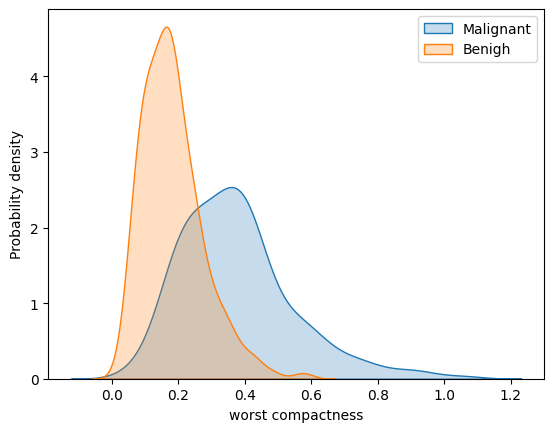

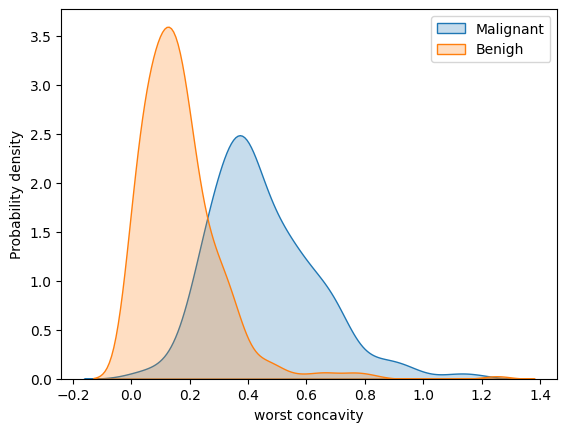

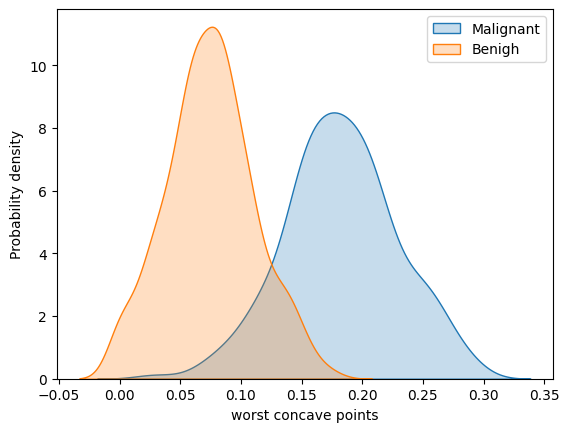

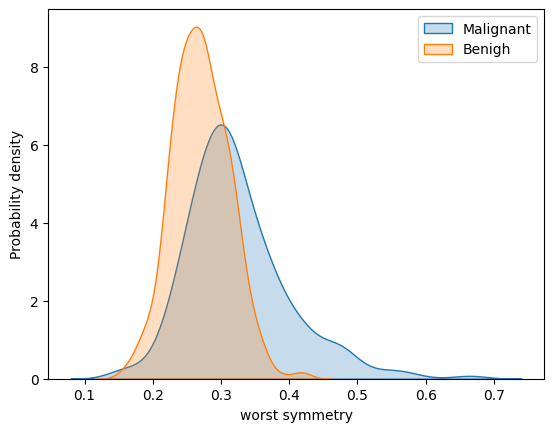

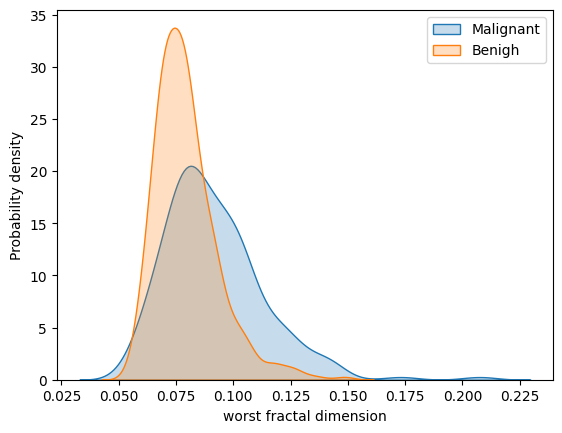

In [6]:
for i in range(bcancer_X.shape[1]):
    sns.kdeplot(bcancer_X[bcancer_y==0,i],fill=True)
    sns.kdeplot(bcancer_X[bcancer_y==1,i],fill=True)

    plt.legend(['Malignant','Benigh'])
    plt.xlabel(bcancer.feature_names[i])
    plt.ylabel('Probability density')
    plt.show()
    plt.close()

Step 2 Train different classification models

Logistic Regression model and the decision boundry

In [7]:
## Select two features to train, change the feature index here to see different effectiveness between features ##
#two features selected to be able to see the decision boundry
selected_features = [0,1]

## Create a classifier and fit it by the training data ##
classifier = linear_model.LogisticRegression(penalty='none',solver='lbfgs').fit(bcancer_X_train[:,selected_features], bcancer_y_train)

InvalidParameterError: The 'penalty' parameter of LogisticRegression must be a str among {'elasticnet', 'l2', 'l1'} or None. Got 'none' instead.

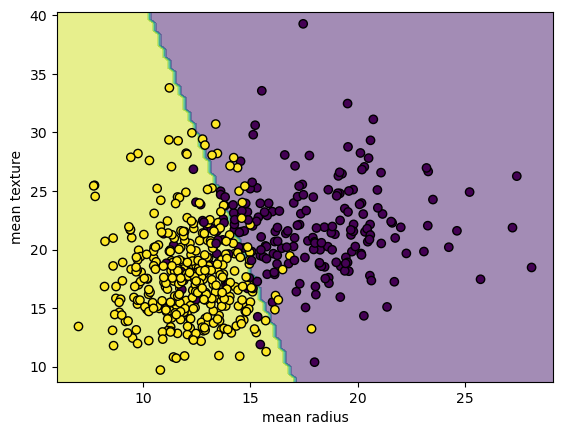

In [ ]:
## Plot decision boundaries in the 2D-dimension feature map ##
disp = DecisionBoundaryDisplay.from_estimator(
     classifier, bcancer_X[:,selected_features], response_method="predict",
     xlabel=bcancer.feature_names[selected_features[0]], ylabel=bcancer.feature_names[selected_features[1]],
     alpha=0.5,
 )
disp.ax_.scatter(bcancer_X[:,selected_features[0]], bcancer_X[:,selected_features[1]], c=bcancer_y, edgecolor="k")

In [ ]:
## Evaluate classifier on test set ##
print('coeficients: {}'.format(np.round(classifier.coef_,3)))
accuracy = classifier.score(bcancer_X_test[:,selected_features], bcancer_y_test)
print('accuracy %.3f' % accuracy)

coeficients: [[-1.019 -0.219]]
accuracy 0.947


Now add regularisation to the classifier (see the example code below), and repeat training to see how regularisation works on the decision boundaries, coeficients, and what's the effect on the testing performance. The options of regularisation criteria can be found in their scikit learn webpage, e.g.  details of [logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression).

In [ ]:
classifier = linear_model.LogisticRegression(penalty='l2',solver='lbfgs').fit(bcancer_X_train[:,selected_features], bcancer_y_train)
print('coeficients: {}'.format(np.round(classifier.coef_,3)))
accuracy = classifier.score(bcancer_X_test[:,selected_features], bcancer_y_test)
print('accuracy %.3f' % accuracy)

coeficients: [[-1.008 -0.218]]
accuracy 0.947


Change the test size to a larger portion (in the second cell and repeat step 2. The regularization may not do good to the model performance when the training set is small, it may cause underfitting of the data.

Use different feature sets and train Logisitc regression and evaluate performance

Random Forest

In [ ]:
#train random forest
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(bcancer_X_train, bcancer_y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
#evaluate performance
predicted = clf.predict(bcancer_X_test)
accuracy_score(bcancer_y_test, predicted)

0.9649122807017544

Train Gradient boosting tree and evaluate the model

Repeat training Random Forest and Gradient Boosting Tree with different classifier variables

Summarise  the key ideas that you have learned about classification models

Kmeans clustering Elbow method

/Users/sk0051/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/sk0051/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/sk0051/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/sk0051/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/Users/sk0051/an

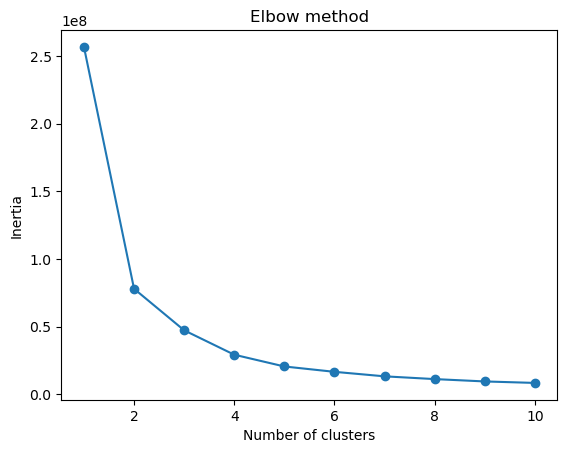

In [ ]:
from sklearn.cluster import KMeans

inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(bcancer_X)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

Hirarchcal Clustering example

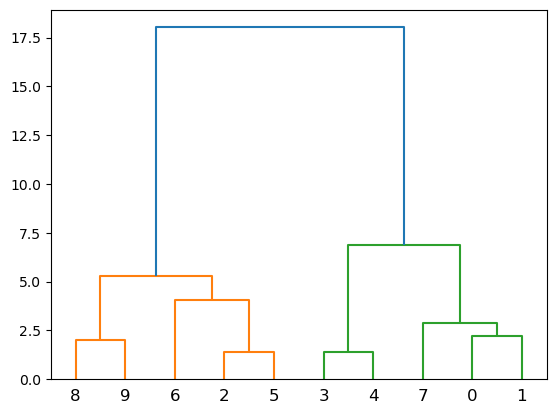

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

data = list(zip(x, y))

linkage_data = linkage(data, method='ward', metric='euclidean')
dendrogram(linkage_data)

plt.show()
# Chibuzor Ojogbo